# Step 2 — Disease GSEA

This notebook performs **pathway-level disease analysis** for the main comparison
in the project:

- **Ulcerative colitis (UC) vs healthy control (HC)**

It uses the exploratory differential expression output from Step 1, converts
**Ensembl gene IDs to gene symbols**, builds a preranked gene list compatible
with Enrichr/MSigDB libraries, and runs GSEA using **gseapy**.

## Inputs expected from Step 1

- `results/tables/GSE235236_UC_vs_HC_quick_DE.tsv`
- `data/processed/GSE235236/*RSEM.genes.results.gz`

## Main outputs

- `results/tables/GSE235236_UC_vs_HC_ranked_gene_symbols_for_GSEA.tsv`
- `results/tables/GSE235236_UC_vs_HC_GSEA_results.tsv`
- `results/tables/GSE235236_UC_vs_HC_GSEA_significant_FDR_0_25.tsv`
- `results/tables/GSE235236_UC_vs_HC_GSEA_significant_FDR_0_05.tsv`
- `results/tables/GSE235236_UC_vs_HC_disease_pathway_signature.tsv`
- `results/figures/GSE235236_UC_vs_HC_top_positive_pathways.png`
- `results/figures/GSE235236_UC_vs_HC_top_negative_pathways.png`
- `results/figures/GSE235236_UC_vs_HC_selected_enrichment_plot.png`

## Important note

In this `gseapy` result format, the actual pathway names are stored in the
**row index**, not in the `Term` column. This notebook resets the index and
uses a dedicated **`Pathway`** column everywhere downstream.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gseapy as gp


## 1. Define paths


In [2]:
PROJECT_DIR = Path("..")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed" / "GSE235236"
RESULTS_TABLES = PROJECT_DIR / "results" / "tables"
RESULTS_FIGURES = PROJECT_DIR / "results" / "figures"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

QUICK_DE_FILE = RESULTS_TABLES / "GSE235236_UC_vs_HC_quick_DE.tsv"

print("Quick DE file:", QUICK_DE_FILE)
print("Quick DE file exists:", QUICK_DE_FILE.exists())


Quick DE file: ../results/tables/GSE235236_UC_vs_HC_quick_DE.tsv
Quick DE file exists: True


## 2. Load exploratory DE results


In [3]:
if not QUICK_DE_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {QUICK_DE_FILE}\n"
        "Run Step 1 first, or place the quick DE file in results/tables/."
    )

quick_de = pd.read_csv(QUICK_DE_FILE, sep="\t", index_col=0)
quick_de.head()


,log2FC,pvalue,padj
gene_id,,,
ENSG00000072415,-0.652677,2.820575e-10,NaN
ENSG00000112079,-0.716881,2.920424e-10,NaN
ENSG00000132305,-0.740530,3.356997e-10,NaN
ENSG00000062485,-0.697230,3.599229e-10,NaN
ENSG00000071189,-0.689006,6.043189e-10,NaN


In [4]:
print("Shape:", quick_de.shape)
print("Columns:", quick_de.columns.tolist())


Shape: (33677, 3)
Columns: ['log2FC', 'pvalue', 'padj']


## 3. Rebuild an Ensembl-to-symbol annotation table from one RSEM file

Step 1 cleaned the count matrix down to Ensembl IDs. For GSEA against Enrichr/MSigDB,
we need **gene symbols**.

The original per-sample RSEM files still contain `gene_id` values like:

- `ENSG00000000003.14_TSPAN6`

From that, we can recover:

- `ensembl_id = ENSG00000000003`
- `gene_symbol = TSPAN6`


In [5]:
rsem_files = sorted(PROCESSED_DIR.glob("*RSEM.genes.results.gz"))

if len(rsem_files) == 0:
    raise FileNotFoundError(
        f"No RSEM files found in {PROCESSED_DIR}.\n"
        "Run Step 1 first so the supplementary GEO archive is extracted."
    )

sample_file = rsem_files[0]
annot = pd.read_csv(sample_file, sep="\t", compression="gzip")[["gene_id"]].copy()

annot["gene_symbol"] = annot["gene_id"].str.split("_").str[1]
annot["ensembl_id"] = annot["gene_id"].str.split("_").str[0].str.split(".").str[0]

annot = annot[["ensembl_id", "gene_symbol"]].drop_duplicates()
annot.head()


,ensembl_id,gene_symbol
0,ENSG00000000003,TSPAN6
1,ENSG00000000005,TNMD
2,ENSG00000000419,DPM1
3,ENSG00000000457,SCYL3
4,ENSG00000000460,C1orf112


In [6]:
print("Annotation table shape:", annot.shape)
print("Missing symbols:", annot["gene_symbol"].isna().sum())


Annotation table shape: (58278, 2)
Missing symbols: 0


## 4. Merge DE results with gene symbols


In [7]:
quick_de = quick_de.reset_index().rename(columns={"gene_id": "ensembl_id"})
quick_de_annot = quick_de.merge(annot, on="ensembl_id", how="left")

print("Total rows:", quick_de_annot.shape[0])
print("Missing gene symbols:", quick_de_annot["gene_symbol"].isna().sum())

quick_de_annot.head()


Total rows: 33710
Missing gene symbols: 0


,ensembl_id,log2FC,pvalue,padj,gene_symbol
0,ENSG00000072415,-0.652677,2.820575e-10,NaN,MPP5
1,ENSG00000112079,-0.716881,2.920424e-10,NaN,STK38
2,ENSG00000132305,-0.740530,3.356997e-10,NaN,IMMT
3,ENSG00000062485,-0.697230,3.599229e-10,NaN,CS
4,ENSG00000071189,-0.689006,6.043189e-10,NaN,SNX13


## 5. Build a gene-symbol-based ranked list

Multiple Ensembl IDs can map to the same gene symbol.
For preranked GSEA, we keep one ranking score per symbol.

Ranking strategy used here:

- `rank_score = log2FC * -log10(pvalue)`

Then:
- drop missing symbols
- compute absolute rank
- keep the strongest row per gene symbol
- convert symbols to uppercase for Enrichr libraries


In [8]:
quick_de_annot = quick_de_annot.dropna(subset=["gene_symbol"]).copy()

quick_de_annot["rank_score"] = (
    quick_de_annot["log2FC"] * -np.log10(quick_de_annot["pvalue"].clip(lower=1e-300))
)

quick_de_annot["abs_rank"] = quick_de_annot["rank_score"].abs()
quick_de_annot = quick_de_annot.sort_values("abs_rank", ascending=False)

quick_de_symbol = quick_de_annot.drop_duplicates(subset=["gene_symbol"]).copy()
quick_de_symbol["gene_symbol"] = quick_de_symbol["gene_symbol"].str.upper()

print("Rows after symbol mapping and deduplication:", quick_de_symbol.shape[0])
quick_de_symbol.head()


Rows after symbol mapping and deduplication: 33442


,ensembl_id,log2FC,pvalue,padj,gene_symbol,rank_score,abs_rank
30,ENSG00000236439,-3.356729,7.748939e-09,NaN,RP11-175B9.3,-27.225613,27.225613
1149,ENSG00000253755,4.683796,1.918753e-04,NaN,IGHGP,17.409581,17.409581
291,ENSG00000284419,3.192982,3.708507e-06,NaN,MIR663A,17.340450,17.340450
58,ENSG00000258947,2.351168,5.199153e-08,NaN,TUBB3,17.126070,17.126070
1064,ENSG00000270149,-4.265822,1.523863e-04,NaN,RP11-544M22.13,-16.282872,16.282872


## 6. Save the corrected ranked gene-symbol file


In [9]:
ranked_symbol_file = RESULTS_TABLES / "GSE235236_UC_vs_HC_ranked_gene_symbols_for_GSEA.tsv"

quick_de_symbol[["gene_symbol", "rank_score"]].to_csv(
    ranked_symbol_file,
    sep="\t",
    index=False
)

print("Saved:", ranked_symbol_file)


Saved: ../results/tables/GSE235236_UC_vs_HC_ranked_gene_symbols_for_GSEA.tsv


## 7. Prepare the preranked series for GSEA


In [10]:
rank_series = quick_de_symbol.set_index("gene_symbol")["rank_score"]
rank_series = rank_series.dropna().sort_values(ascending=False)

print("Number of ranked genes:", rank_series.shape[0])
print("Top rank score:", rank_series.iloc[0])
print("Bottom rank score:", rank_series.iloc[-1])

rank_series.head()


Number of ranked genes: 33437
Top rank score: 17.409580966657888
Bottom rank score: -27.22561284139491


gene_symbol
IGHGP       17.409581
MIR663A     17.340450
TUBB3       17.126070
MT-TM       16.147184
SERPINB3    15.559618
Name: rank_score, dtype: float64

## 8. Choose the gene set collection

For a first disease-level pathway analysis, a strong default is:

- **MSigDB_Hallmark_2020**

This is cleaner and easier to interpret than a very large ontology collection.


In [11]:
gene_set_library = "MSigDB_Hallmark_2020"
gene_set_library


'MSigDB_Hallmark_2020'

## 9. Run preranked GSEA


In [12]:
pre_res = gp.prerank(
    rnk=rank_series,
    gene_sets=gene_set_library,
    threads=4,
    min_size=15,
    max_size=500,
    permutation_num=1000,
    seed=42,
    verbose=True,
    outdir=None
)


2026-04-19 17:13:01,748 [INFO] Input gene rankings contains duplicated IDs
2026-04-19 17:13:01,755 [WARNING] Duplicated values found in preranked stats: 5.90% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-19 17:13:01,755 [INFO] Parsing data files for GSEA.............................
2026-04-19 17:13:01,809 [INFO] Enrichr library gene sets already downloaded in: /Users/vaibhav.mh/.cache/gseapy, use local file
2026-04-19 17:13:01,828 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-19 17:13:01,829 [INFO] 0050 gene_sets used for further statistical testing.....
2026-04-19 17:13:01,829 [INFO] Start to run GSEA...Might take a while..................
2026-04-19 17:13:14,905 [INFO] Congratulations. GSEApy runs successfully................



## 10. Inspect raw GSEA results


In [13]:
gsea_res = pre_res.res2d.copy()
gsea_res.head()


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Oxidative Phosphorylation,-0.718172,-2.058361,0.0,0.0,0.0,90/185,16.35%,ACADSB;IMMT;NDUFS1;CS;BDH2;HADHA;ALDH6A1;HADHB...
1,prerank,Epithelial Mesenchymal Transition,0.667887,2.0187,0.0,0.0,0.0,75/198,13.65%,COL7A1;CXCL6;SPP1;LOXL1;BGN;PDLIM4;LGALS1;INHB...
2,prerank,TNF-alpha Signaling via NF-kB,0.596876,1.789889,0.0,0.003271,0.005,54/199,13.18%,PHLDA2;FJX1;SLC2A6;G0S2;SPHK1;CEBPD;JUNB;CXCL6...
3,prerank,Inflammatory Response,0.585253,1.773973,0.0,0.002181,0.005,56/199,12.01%,CD70;SPHK1;PROK2;OSM;CSF3;CXCL6;CSF3R;CHST2;CC...
4,prerank,Fatty Acid Metabolism,-0.63659,-1.76532,0.0,0.0,0.0,52/154,12.13%,ADH1C;HMGCS2;HADHB;MAOA;CA2;ACSL5;ETFDH;HIBCH;...


In [14]:
print("GSEA result shape:", gsea_res.shape)
print("Columns:", gsea_res.columns.tolist())


GSEA result shape: (50, 10)
Columns: ['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']


## 11. Standardize common result column names and create a real Pathway column

Different `gseapy` versions vary slightly in result column naming.

In this output format, the actual pathway names are stored in the **index**,
while the `Term` column may just contain `prerank`. So we reset the index and
use a dedicated `Pathway` column everywhere downstream.


In [15]:
rename_map = {}
for col in gsea_res.columns:
    col_lower = str(col).lower().strip()
    if col_lower == "es":
        rename_map[col] = "ES"
    elif col_lower == "nes":
        rename_map[col] = "NES"
    elif col_lower in {"pval", "nom p-val"}:
        rename_map[col] = "pval"
    elif col_lower in {"fdr q-val", "fdr", "padj"}:
        rename_map[col] = "FDR"

gsea_res = gsea_res.rename(columns=rename_map)

# Keep the first instance of any duplicated column names
gsea_res = gsea_res.loc[:, ~gsea_res.columns.duplicated()].copy()

# Turn index into a real pathway column
gsea_res = gsea_res.reset_index().rename(columns={"index": "Pathway"})

# Clean core columns
gsea_res["Pathway"] = gsea_res["Pathway"].astype(str)

if "NES" in gsea_res.columns:
    gsea_res["NES"] = pd.to_numeric(gsea_res["NES"], errors="coerce")

if "FDR" in gsea_res.columns:
    gsea_res["FDR"] = pd.to_numeric(gsea_res["FDR"], errors="coerce")

print(gsea_res.columns.tolist())
gsea_res.head()


['Pathway', 'Name', 'Term', 'ES', 'NES', 'pval', 'FDR', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']


,Pathway,Name,Term,ES,NES,pval,FDR,FWER p-val,Tag %,Gene %,Lead_genes
0,0,prerank,Oxidative Phosphorylation,-0.718172,-2.058361,0.0,0.000000,0.0,90/185,16.35%,ACADSB;IMMT;NDUFS1;CS;BDH2;HADHA;ALDH6A1;HADHB...
1,1,prerank,Epithelial Mesenchymal Transition,0.667887,2.018700,0.0,0.000000,0.0,75/198,13.65%,COL7A1;CXCL6;SPP1;LOXL1;BGN;PDLIM4;LGALS1;INHB...
2,2,prerank,TNF-alpha Signaling via NF-kB,0.596876,1.789889,0.0,0.003271,0.005,54/199,13.18%,PHLDA2;FJX1;SLC2A6;G0S2;SPHK1;CEBPD;JUNB;CXCL6...
3,3,prerank,Inflammatory Response,0.585253,1.773973,0.0,0.002181,0.005,56/199,12.01%,CD70;SPHK1;PROK2;OSM;CSF3;CXCL6;CSF3R;CHST2;CC...
4,4,prerank,Fatty Acid Metabolism,-0.63659,-1.765320,0.0,0.000000,0.0,52/154,12.13%,ADH1C;HMGCS2;HADHB;MAOA;CA2;ACSL5;ETFDH;HIBCH;...


## 12. Save the full GSEA results table


In [16]:
output_gsea_table = RESULTS_TABLES / "GSE235236_UC_vs_HC_GSEA_results.tsv"
gsea_res.to_csv(output_gsea_table, sep="\t", index=False)

print("Saved:", output_gsea_table)


Saved: ../results/tables/GSE235236_UC_vs_HC_GSEA_results.tsv


## 13. Filter significant pathways

Two common thresholds are used here:

- **FDR < 0.25** for broad exploratory GSEA
- **FDR < 0.05** for stricter interpretation


In [17]:
if "FDR" not in gsea_res.columns:
    raise ValueError(
        "Could not find an FDR column in the GSEA results. "
        "Check the result table columns from gseapy."
    )

if "NES" not in gsea_res.columns:
    raise ValueError(
        "Could not find an NES column in the GSEA results. "
        "Check the result table columns from gseapy."
    )

sig_gsea = gsea_res[gsea_res["FDR"] < 0.25].copy()
sig_gsea = sig_gsea.sort_values("NES", ascending=False)

strict_gsea = gsea_res[gsea_res["FDR"] < 0.05].copy()
strict_gsea = strict_gsea.sort_values("NES", ascending=False)

print("Significant pathways at FDR < 0.25:", sig_gsea.shape[0])
print("Significant pathways at FDR < 0.05:", strict_gsea.shape[0])


Significant pathways at FDR < 0.25: 27
Significant pathways at FDR < 0.05: 19


## 14. Save filtered pathway tables


In [18]:
sig_gsea.to_csv(
    RESULTS_TABLES / "GSE235236_UC_vs_HC_GSEA_significant_FDR_0_25.tsv",
    sep="\t",
    index=False
)

strict_gsea.to_csv(
    RESULTS_TABLES / "GSE235236_UC_vs_HC_GSEA_significant_FDR_0_05.tsv",
    sep="\t",
    index=False
)

print("Saved filtered GSEA tables.")


Saved filtered GSEA tables.


## 15. Plot the top positively enriched pathways


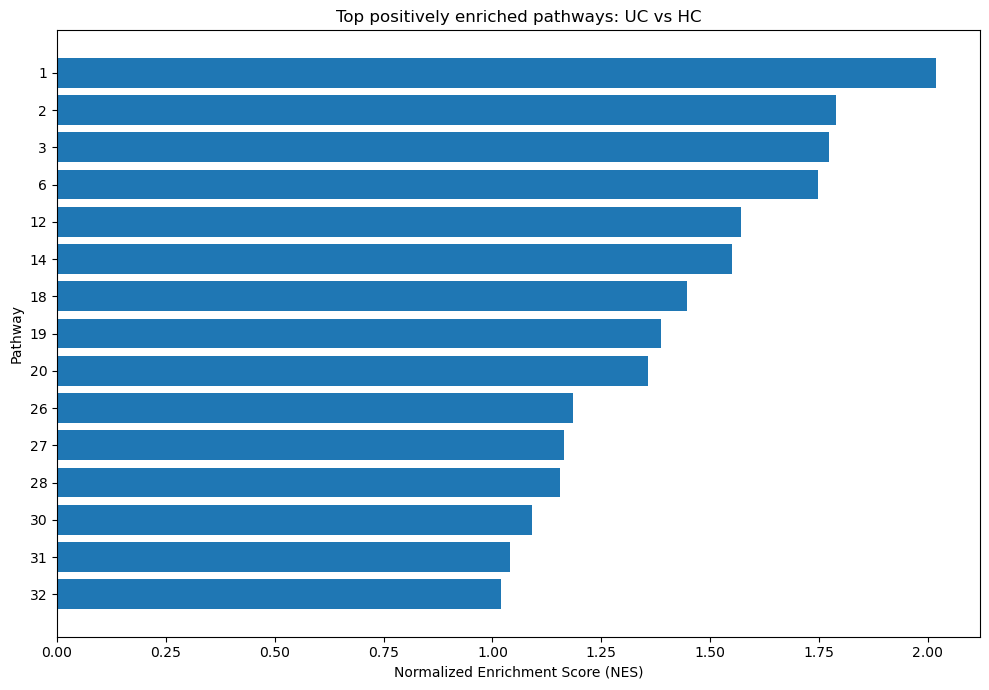

In [19]:
top_pos = gsea_res.sort_values("NES", ascending=False).head(15).copy()
top_pos = top_pos.dropna(subset=["NES"])
top_pos = top_pos.iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_pos["Pathway"], top_pos["NES"])
plt.xlabel("Normalized Enrichment Score (NES)")
plt.ylabel("Pathway")
plt.title("Top positively enriched pathways: UC vs HC")
plt.tight_layout()
plt.savefig(
    RESULTS_FIGURES / "GSE235236_UC_vs_HC_top_positive_pathways.png",
    dpi=300
)
plt.show()


## 16. Plot the top negatively enriched pathways


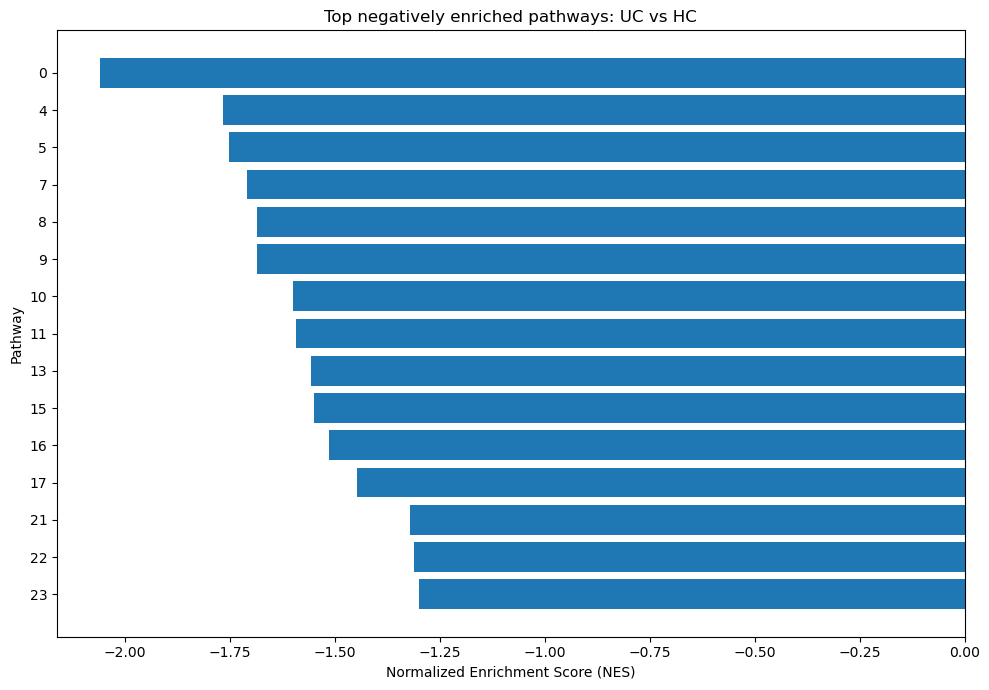

In [20]:
top_neg = gsea_res.sort_values("NES", ascending=True).head(15).copy()
top_neg = top_neg.dropna(subset=["NES"])
top_neg = top_neg.iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_neg["Pathway"], top_neg["NES"])
plt.xlabel("Normalized Enrichment Score (NES)")
plt.ylabel("Pathway")
plt.title("Top negatively enriched pathways: UC vs HC")
plt.tight_layout()
plt.savefig(
    RESULTS_FIGURES / "GSE235236_UC_vs_HC_top_negative_pathways.png",
    dpi=300
)
plt.show()


## 17. Inspect the leading disease pathways


In [21]:
top_pos[["Pathway", "NES", "FDR"]].sort_values("NES", ascending=False).head(10)


,Pathway,NES,FDR
1,1,2.018700,0.000000
2,2,1.789889,0.003271
3,3,1.773973,0.002181
6,6,1.747378,0.002617
12,12,1.570056,0.015439
14,14,1.550329,0.016137
18,18,1.445608,0.043550
19,19,1.387639,0.066727
20,20,1.357672,0.079375
26,26,1.184841,0.318720


In [22]:
top_neg[["Pathway", "NES", "FDR"]].sort_values("NES", ascending=True).head(10)


,Pathway,NES,FDR
0,0,-2.058361,0.000000
4,4,-1.765320,0.000000
5,5,-1.751985,0.000000
7,7,-1.707785,0.000996
8,8,-1.684905,0.001275
9,9,-1.684093,0.001062
10,10,-1.598451,0.004097
11,11,-1.592902,0.003784
13,13,-1.555326,0.006638
15,15,-1.548715,0.006373


## 18. Optional enrichment plot for one pathway

This version selects a pathway safely from `pre_res.results`, which avoids
table/dictionary key mismatches across `gseapy` versions.


In [23]:
result_nes = {
    term: res_dict["nes"]
    for term, res_dict in pre_res.results.items()
    if isinstance(res_dict, dict) and "nes" in res_dict
}

selected_term = max(result_nes, key=result_nes.get)
print("Selected pathway:", selected_term)
print("NES:", result_nes[selected_term])


Selected pathway: Epithelial Mesenchymal Transition
NES: 2.0186996644329365


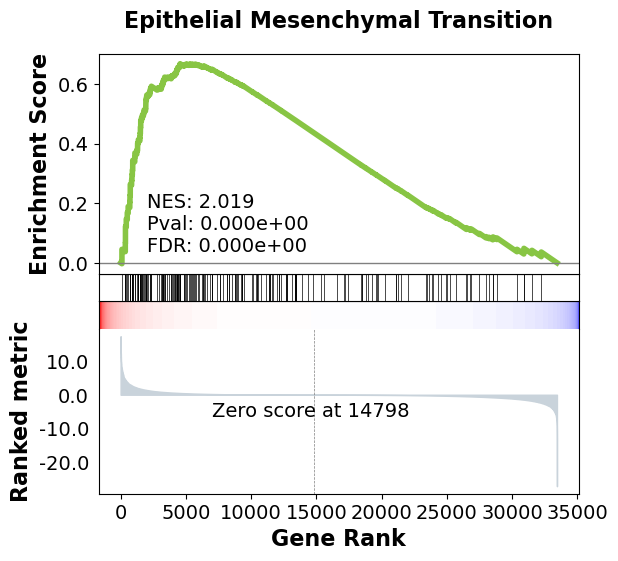

In [24]:
gp.gseaplot(
    rank_metric=pre_res.ranking,
    term=selected_term,
    **pre_res.results[selected_term]
)

plt.savefig(
    RESULTS_FIGURES / "GSE235236_UC_vs_HC_selected_enrichment_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 19. Create a compact disease pathway signature table


In [25]:
disease_pathway_signature = gsea_res[["Pathway", "NES", "FDR"]].copy()
disease_pathway_signature = disease_pathway_signature.sort_values("NES", ascending=False)

disease_pathway_signature.to_csv(
    RESULTS_TABLES / "GSE235236_UC_vs_HC_disease_pathway_signature.tsv",
    sep="\t",
    index=False
)

disease_pathway_signature.head()


,Pathway,NES,FDR
1,1,2.018700,0.000000
2,2,1.789889,0.003271
3,3,1.773973,0.002181
6,6,1.747378,0.002617
12,12,1.570056,0.015439


## 20. Interpretation notes

At this stage, you should look for patterns such as:

- inflammatory pathways enriched in UC
- immune activation
- cytokine signaling
- epithelial stress or barrier dysfunction
- pathways that are relatively suppressed in disease

This is the bridge from:
- gene-level disease signals
to
- pathway-level disease biology


## 21. Expected outputs from this notebook

Main tables:
- `results/tables/GSE235236_UC_vs_HC_ranked_gene_symbols_for_GSEA.tsv`
- `results/tables/GSE235236_UC_vs_HC_GSEA_results.tsv`
- `results/tables/GSE235236_UC_vs_HC_GSEA_significant_FDR_0_25.tsv`
- `results/tables/GSE235236_UC_vs_HC_GSEA_significant_FDR_0_05.tsv`
- `results/tables/GSE235236_UC_vs_HC_disease_pathway_signature.tsv`

Main figures:
- `results/figures/GSE235236_UC_vs_HC_top_positive_pathways.png`
- `results/figures/GSE235236_UC_vs_HC_top_negative_pathways.png`
- `results/figures/GSE235236_UC_vs_HC_selected_enrichment_plot.png`


## 22. Recommended next step

Move to:

- `03_perturbation_gsea.ipynb`

Goal of the next notebook:
- build pathway signatures for perturbation data
- put disease and perturbation pathways into the same space
- prepare for anticorrelation ranking
